In [1]:
#######################################################################
#######################################################################
##
## This notebook is quantifying the HCR total intensity within the cells in the context of HCR Kazald1
## 
#######################################################################
#######################################################################

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import copy
import tifffile

In [13]:
from skimage.io import imread
from skimage.io import imsave
from skimage import filters
from skimage.filters import gaussian
from skimage import morphology
from skimage import measure
from skimage import io, exposure, img_as_ubyte
from skimage.transform import rescale

In [4]:
#from scipy import ndimage as ndi
from skimage import (exposure, feature, filters, io, measure,
                      morphology, restoration, segmentation, transform,
                      util)

In [5]:
import napari
from napari.utils import nbscreenshot

In [6]:
from pyclesperanto_prototype import imshow
import pyclesperanto_prototype as cle
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [7]:
cle.available_device_names()
# For 3D processing, powerful graphics
# processing units might be necessary
cle.select_device('TX')

/Users/jingkui.wang/miniforge3/envs/neuron_branching/lib/python3.9/site-packages/pyclesperanto_prototype/_tier0/_device.py:77: UserWarning: No OpenCL device found with TX in their name. Using Apple M1 Max instead.
  warnings.warn(f"No OpenCL device found with {name} in their name. Using {device.name} instead.")


<Apple M1 Max on Platform: Apple (2 refs)>

In [8]:
#import czifile
from aicsimageio import AICSImage
from aicsimageio.writers import OmeTiffWriter

In [9]:
inputDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1"
#fileName = '2d-Right2-Stitching.czi'
#fileName = "Right4-Stitching.czi"
#fileName = "3d-Right4-Stitching.czi"
fileName = "11dLNP4-limb3-20x-01(1)-Airyscan Processing-01.czi"

fileName = "11d_LNP4_20x_limb2(1)-Airyscan Processing-02.czi"

fileName = "11dpi_BL_an1_20x_Airyscan_07.czi"

outDir = inputDir + '/results/'

if not os.path.exists(outDir):
    os.makedirs(outDir)

print(outDir)

/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/results/


In [11]:
## read czi file (original code https://biapol.github.io/Image-data-science-with-Python-and-Napari-EPFL2022/day2b_Working_with_Images/04_Image_file_formats.html)
#img = czifile.imread(os.path.join(inputDir, fileName))
#img.shape
#czi_dimstring = img.axes
# shape will give you the dimensions of the array
#czi_shapeinfo = img.shape

In [12]:
## read czi file (https://forum.image.sc/t/reading-czi-file-in-python/39768/3)
img = AICSImage(os.path.join(inputDir, fileName))

In [13]:
image = img.data #returns 6D STCZYX numpy array

In [14]:
print(image.shape)
print(img.dims)  # returns string "STCZYX"
print(img.shape)  # returns tuple of dimension sizes in STCZYX order

(1, 4, 1, 21949, 15782)
<Dimensions [T: 1, C: 4, Z: 1, Y: 21949, X: 15782]>
(1, 4, 1, 21949, 15782)


In [15]:
# Metadata Reading (https://allencellmodeling.github.io/aicsimageio/index.html)
img.channel_names  # returns a list of string channel names found in the metadata

[np.str_('ChA-T1'), np.str_('ChA-T2'), np.str_('ChA-T3'), np.str_('ChA-T4')]

In [16]:
#print(img.physical_pixel_sizes.Z)  # no Z dimension
print(img.physical_pixel_sizes.Y)  # returns the Y dimension pixel size as found in the metadata
print(img.physical_pixel_sizes.X)  # returns the X dimension pixel size as found in the metadata

0.061810168997668995
0.061810168997668995


In [25]:
hcr_c1 = img.get_image_data("ZYX", C=0, S=0, T=0) # Kazald1, the signal to quantify
prrxCherry_c2 = img.get_image_data("ZYX", C=1, S=0, T=0) # connective tissue cells, signals in the cytoplasm can be used as cell masks
lnpGFP_c3 = img.get_image_data("ZYX", C=2, S=0, T=0) # also cytoplasm, marking cells with lnp, in blastema there is no lnp-GFP, because no injection in blatema, even in the CSD, blood cell make autofluerence
dapi_c4 =  img.get_image_data("ZYX", C=3, S=0, T=0)# dapi channel 

In [26]:
print(dapi_c4.shape)
print(prrxCherry_c2.shape)

(1, 21949, 15782)
(1, 21949, 15782)


In [27]:
fileName.removesuffix('.czi')

'11dpi_BL_an1_20x_Airyscan_07'

In [28]:
# Output two-channel TIFF
output_file = "/Users/jingkui.wang/workspace/imp/image_analysis_test/results/quantify_HCR/" +  fileName.removesuffix('.czi') + ".tif"
print(output_file)

/Users/jingkui.wang/workspace/imp/image_analysis_test/results/quantify_HCR/11dpi_BL_an1_20x_Airyscan_07.tif


In [29]:
## ignore the z stack channel
print(dapi_c4[0].shape)
print(prrxCherry_c2[0].shape)
cellmarker = prrxCherry_c2[0]
dapi = dapi_c4[0]

(21949, 15782)
(21949, 15782)


In [30]:
np.max(cellmarker)

np.uint16(65535)

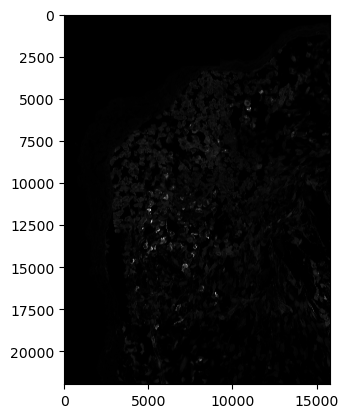

In [31]:
plt.imshow(cellmarker, cmap='gray')

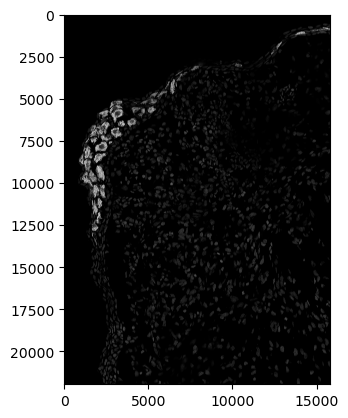

In [32]:
plt.imshow(dapi, cmap='gray')

In [33]:
# Stack them into a (channels, height, width) image
two_channel_image = np.stack([cellmarker, dapi], axis=0)

In [34]:
two_channel_image.shape

(2, 21949, 15782)

In [35]:
# Save as an ImageJ-compatible TIFF, labeling axes as CYX
tifffile.imwrite(
    output_file,
    two_channel_image,
    imagej=True,
    metadata={"axes": "CYX"}
)

In [36]:
## convert 16-bit to 8 bit
from skimage import io, exposure, img_as_ubyte

In [38]:
np.max(cellmarker), np.min(cellmarker)

(np.uint16(65535), np.uint16(0))

In [40]:
#cellmarker_rescaled = exposure.rescale_intensity(cellmarker, in_range='image', out_range=(0, 65535))
cellmarker8 = img_as_ubyte(cellmarker)
np.max(cellmarker8), np.min(cellmarker8)

(np.uint8(255), np.uint8(0))

In [41]:
dapi8 = img_as_ubyte(dapi)
np.max(dapi8), np.min(dapi8)

(np.uint8(255), np.uint8(0))

In [42]:
output_file = "/Users/jingkui.wang/workspace/imp/image_analysis_test/results/quantify_HCR/" +  fileName.removesuffix('.czi') + "_8bit.tif"
print(output_file)

/Users/jingkui.wang/workspace/imp/image_analysis_test/results/quantify_HCR/11dpi_BL_an1_20x_Airyscan_07_8bit.tif


In [43]:
two_channel_image = np.stack([cellmarker8, dapi8], axis=0)
# Save as an ImageJ-compatible TIFF, labeling axes as CYX
tifffile.imwrite(
    output_file,
    two_channel_image,
    imagej=True,
    metadata={"axes": "CYX"}
)

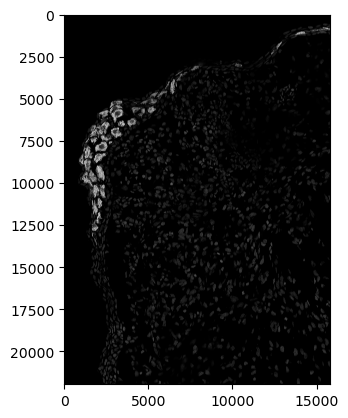

In [44]:
plt.imshow(dapi, cmap='gray')

In [ ]:
#bone_mask_cropped[0:500, 400:1200]

In [48]:
output_file = "/Users/jingkui.wang/workspace/imp/image_analysis_test/results/quantify_HCR/" +  fileName.removesuffix('.czi') + "_8bit_cropped_2.tif"
print(output_file)

/Users/jingkui.wang/workspace/imp/image_analysis_test/results/quantify_HCR/11dpi_BL_an1_20x_Airyscan_07_8bit_cropped_2.tif


In [49]:
two_channel_image = np.stack([cellmarker8[10000:12000, 5000:7000], dapi8[10000:12000, 5000:7000]], axis=0)
# Save as an ImageJ-compatible TIFF, labeling axes as CYX
tifffile.imwrite(
    output_file,
    two_channel_image,
    imagej=True,
    metadata={"axes": "CYX"}
)

In [50]:
two_channel_image.shape

(2, 2000, 2000)

In [ ]:
#########################################################
#########################################################
### here is the save cell markers and dapi for all images 
#########################################################
#########################################################

In [14]:
print(inputDir)

/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1


In [15]:
outDir = inputDir + "/images"

if not os.path.exists(outDir):
    os.makedirs(outDir)

print(outDir)

/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/images


In [16]:
for nm in os.listdir(inputDir):
    #if "C4_CystMask.tiff" in nm:
    if ".czi" in nm:
        print(nm)
        #fileName = nm.replace('_C4_CystMask.tiff','')
        fileName = nm.replace('.czi','')
        
        ## read czi file (https://forum.image.sc/t/reading-czi-file-in-python/39768/3)
        img = AICSImage(os.path.join(inputDir, fileName + '.czi'))
        image = img.data #returns 6D STCZYX numpy array
        
        print(image.shape)
        #print(img.dims)  # returns string "STCZYX"
        #print(img.shape)  # returns tuple of dimension sizes in STCZYX order
        print(img.physical_pixel_sizes.Y)  # returns the Y dimension pixel size as found in the metadata
        print(img.physical_pixel_sizes.X)  # returns the X dimension pixel size as found in the metadata
        
        prrxCherry_c2 = img.get_image_data("ZYX", C=1, S=0, T=0) # connective tissue cells, signals in the cytoplasm can be used as cell masks
        dapi_c4 =  img.get_image_data("ZYX", C=3, S=0, T=0)# dapi channel 
        
        print(dapi_c4[0].shape)
        print(prrxCherry_c2[0].shape)
        
        cellmarker = prrxCherry_c2[0]
        dapi = dapi_c4[0]
        
        ## mild denoising
        sigma = 1.0
        cellmarker = gaussian(cellmarker, sigma=sigma)
        dapi = gaussian(dapi, sigma=sigma)
        
        print([np.min(cellmarker), np.max(cellmarker)])
        print([np.min(dapi), np.max(dapi)])
        
        ## convert 16bit to 8bit to reduce the image size
        #cellmarker_rescaled = exposure.rescale_intensity(cellmarker, in_range='image', out_range=(0, 65535))
        cellmarker8 = img_as_ubyte(cellmarker)
        dapi8 = img_as_ubyte(dapi)
        print([np.min(cellmarker8), np.max(cellmarker8)])
        print([np.min(dapi8), np.max(dapi8)])
        
        ## downsample the images
        factor = 0.5  # downsample to 50%
        cellmarker8 = rescale(cellmarker8, factor, preserve_range=True, anti_aliasing=True, order=1).astype(cellmarker8.dtype)
        dapi8 = rescale(dapi8, factor, preserve_range=True, anti_aliasing = True, order=1).astype(dapi8.dtype)
        
        print(cellmarker8.shape)
        print(dapi8.shape)
        ## save the two channels images
        output_file = os.path.join(outDir, fileName + "_8bit.tif")
        
        print(output_file)
        
        two_channel_image = np.stack([cellmarker8, dapi8], axis=0)
        # Save as an ImageJ-compatible TIFF, labeling axes as CYX
        tifffile.imwrite(
            output_file,
            two_channel_image,
            imagej=True,
            metadata={"axes": "CYX"}
        )
        

11dpi_LNP2_an2_20x_Airyscan_09.czi
(1, 4, 1, 18877, 68296)
0.061810168997668995
0.061810168997668995
(18877, 68296)
(18877, 68296)
[np.float64(0.0), np.float64(0.9932205968451748)]
[np.float64(0.0), np.float64(0.537209744373853)]
[np.uint8(0), np.uint8(253)]
[np.uint8(0), np.uint8(137)]
(9438, 34148)
(9438, 34148)
/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/images/11dpi_LNP2_an2_20x_Airyscan_09_8bit.tif
11d_LNP3_20x_limb2_Airyscan_09.czi
(1, 4, 1, 22024, 52847)
0.061810168997668995
0.061810168997668995
(22024, 52847)
(22024, 52847)
[np.float64(0.0), np.float64(1.0)]
[np.float64(0.0), np.float64(0.7255450664265867)]
[np.uint8(0), np.uint8(255)]
[np.uint8(0), np.uint8(185)]
(11012, 26424)
(11012, 26424)
/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/images/11d_LNP3_20x_limb2_Airyscan_09_8bit.tif
11d_LNP3_20x_limb1__Airyscan_05.czi
(1, 4, 1, 18868, 40489)
0.061810168997668995
0.0618101

In [ ]:
#########################################################
#########################################################
### to reduce the image sizes, try to crop the image size based on. the region of interest  
#########################################################
#########################################################

In [17]:
outDir = inputDir + "/images_cropped"
if not os.path.exists(outDir):
    os.makedirs(outDir)

print(outDir)

/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/images_cropped


In [73]:
crop_coord = pd.read_csv("/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/HCR_crop_coordinates.csv", sep = ";")

In [74]:
crop_coord

,file,point1_X,point1_Y,point2_X,point2_Y,point3_X,point3_Y,point4_X,point4_Y
0,11d_LNP3_20x_limb1__Airyscan_05.czi,414,243,435,851,2110,491,2072,1013
1,11d_LNP3_20x_limb3_Airyscan_04.czi,134,79,129,290,1173,78,1091,356
2,11d_LNP4_20x_limb1_Airyscan_03.czi,403,263,389,855,1851,467,2080,1036
3,11d_LNP4_20x_limb2_Airyscan_02.czi,116,110,145,346,797,150,878,350
4,11dLNP4_limb3_20x_Airyscan_01.czi,395,424,463,1320,1854,175,1911,1068
5,11dpi_BL_an1_20x_Airyscan_07.czi,561,198,168,516,969,518,722,874
6,11dpi_BL_an2_20x_Airyscan_06.czi,354,587,710,866,897,399,1242,627
7,11dpi_LNP1_20x_an2_Airyscan_12.czi,123,6,146,238,1066,41,1007,268
8,11dpi_LNP1_20x_an3_Airyscan_11.czi,118,30,160,276,1088,39,1074,226
9,11dpi_LNP1_20x_Airyscan_13.czi,102,131,187,339,1207,51,1194,258


In [75]:
#crop_coord.loc[5, :]

In [76]:
nm = "11d_LNP4_20x_limb1_Airyscan_03.czi"

In [77]:
index = crop_coord.index[crop_coord["file"] == nm]
print(index)

Index([2], dtype='int64')


In [78]:
crop = crop_coord.loc[index, :]
crop = crop.to_numpy()
crop = crop[0, 1:].astype(int)

In [79]:
print(crop.shape)
crop

(8,)


array([ 403,  263,  389,  855, 1851,  467, 2080, 1036])

In [80]:
crop_x = crop[[0, 2, 4, 6]]
crop_y = crop[[1, 3, 5, 7]]
print(crop_x)
print(crop_y)

[ 403  389 1851 2080]
[ 263  855  467 1036]


In [81]:
crop_px_x = np.round(crop_x/0.061810168997668995).astype(int)
crop_px_y = np.round(crop_y/0.061810168997668995).astype(int)

In [82]:
print(crop_px_x)
print(crop_px_y)

[ 6520  6293 29947 33651]
[ 4255 13833  7555 16761]


In [71]:
np.round(crop_px_x).astype(int)

array([ 6520,  6293, 29947, 33651])

In [83]:
outDir = inputDir + "/images_cropped"
if not os.path.exists(outDir):
    os.makedirs(outDir)

print(outDir)

/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/images_cropped


In [84]:
crop_coord = pd.read_csv("/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/HCR_crop_coordinates.csv", sep = ";")

In [85]:
for nm in os.listdir(inputDir):
    #if "C4_CystMask.tiff" in nm:
    if ".czi" in nm:
        print('--------------------------------------')
        print(nm)
        
        #fileName = nm.replace('_C4_CystMask.tiff','')
        fileName = nm.replace('.czi','')
        
        ## find the matching crop coordinates
        index = crop_coord.index[crop_coord["file"] == nm]
        print(index)
        
        crop = crop_coord.loc[index, :]
        crop = crop.to_numpy()
        crop = crop[0, 1:].astype(int)
        crop_x = crop[[0, 2, 4, 6]]
        crop_y = crop[[1, 3, 5, 7]]
        print(crop_x)
        print(crop_y)
        
        ## convert the micron to pixel coordinates
        crop_px_x = np.round(crop_x/0.061810168997668995).astype(int)
        crop_px_y = np.round(crop_y/0.061810168997668995).astype(int)
        print(crop_px_x)
        print(crop_px_y)
        
        ## read czi file (https://forum.image.sc/t/reading-czi-file-in-python/39768/3)
        img = AICSImage(os.path.join(inputDir, fileName + '.czi'))
        image = img.data #returns 6D STCZYX numpy array
        
        print(image.shape)
        #print(img.dims)  # returns string "STCZYX"
        #print(img.shape)  # returns tuple of dimension sizes in STCZYX order
        print(img.physical_pixel_sizes.Y)  # returns the Y dimension pixel size as found in the metadata
        print(img.physical_pixel_sizes.X)  # returns the X dimension pixel size as found in the metadata
        
        prrxCherry_c2 = img.get_image_data("ZYX", C=1, S=0, T=0) # connective tissue cells, signals in the cytoplasm can be used as cell masks
        dapi_c4 =  img.get_image_data("ZYX", C=3, S=0, T=0)# dapi channel 
        
        print(dapi_c4[0].shape)
        print(prrxCherry_c2[0].shape)
        
        cellmarker = prrxCherry_c2[0]
        dapi = dapi_c4[0]
        
        ## mild denoising
        print('-- denoising with gaussian filter --')
        sigma = 1.0
        cellmarker = gaussian(cellmarker, sigma=sigma)
        dapi = gaussian(dapi, sigma=sigma)
        
        print([np.min(cellmarker), np.max(cellmarker)])
        print([np.min(dapi), np.max(dapi)])
        
        ## convert 16bit to 8bit to reduce the image size
        #cellmarker_rescaled = exposure.rescale_intensity(cellmarker, in_range='image', out_range=(0, 65535))
        print('-- converting 16bit to 8 bit --')
        cellmarker8 = img_as_ubyte(cellmarker)
        dapi8 = img_as_ubyte(dapi)
        print([np.min(cellmarker8), np.max(cellmarker8)])
        print([np.min(dapi8), np.max(dapi8)])
        
        ## downsample the images
        #factor = 0.5  # downsample to 50%
        #cellmarker8 = rescale(cellmarker8, factor, preserve_range=True, anti_aliasing=True, order=1).astype(cellmarker8.dtype)
        #dapi8 = rescale(dapi8, factor, preserve_range=True, anti_aliasing = True, order=1).astype(dapi8.dtype)
        
        ## manual crop by specifying the y-axis and x-axis based on Nastya's manual coordinates
        # e.g. bone_mask_cropped = bone_mask_cropped[0:500, 400:1200]
        print('-- cropping --')
        cellmarker8 = cellmarker8[np.min(crop_px_y):np.max(crop_px_y), np.min(crop_px_x):np.max(crop_px_x)]
        dapi8 = dapi8[np.min(crop_px_y):np.max(crop_px_y), np.min(crop_px_x):np.max(crop_px_x)]
        
        print(cellmarker8.shape)
        print(dapi8.shape)
        
        ## save the two channels images
        output_file = os.path.join(outDir, fileName + "_8bit_cropped.tif")
        
        print(output_file)
        
        two_channel_image = np.stack([cellmarker8, dapi8], axis=0)
        # Save as an ImageJ-compatible TIFF, labeling axes as CYX
        tifffile.imwrite(
            output_file,
            two_channel_image,
            imagej=True,
            metadata={"axes": "CYX"}
        )
        

11dpi_LNP2_an2_20x_Airyscan_09.czi
Index([11], dtype='int64')
[ 256  171 1266 1242]
[128 287 127 334]
[ 4142  2767 20482 20094]
[2071 4643 2055 5404]
(1, 4, 1, 18877, 68296)
0.061810168997668995
0.061810168997668995
(18877, 68296)
(18877, 68296)
-- denoising with gaussian filter --
[np.float64(0.0), np.float64(0.9932205968451748)]
[np.float64(0.0), np.float64(0.537209744373853)]
-- converting 16bit to 8 bit --
[np.uint8(0), np.uint8(253)]
[np.uint8(0), np.uint8(137)]
-- cropping --
(3349, 17715)
(3349, 17715)
/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/HCR_Kazald1/images_cropped/11dpi_LNP2_an2_20x_Airyscan_09_8bit_cropped.tif
11d_LNP3_20x_limb2_Airyscan_09.czi
Index([13], dtype='int64')
[105  68 738 726]
[101 273  34 198]
[ 1699  1100 11940 11746]
[1634 4417  550 3203]
(1, 4, 1, 22024, 52847)
0.061810168997668995
0.061810168997668995
(22024, 52847)
(22024, 52847)
-- denoising with gaussian filter --
[np.float64(0.0), np.float64(1.0)]
[np.float6